In [ ]:
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
hearth_disease_recognition_path = kagglehub.competition_download('super-ai-engineer-ss-6-heart-disease-prediction')

100%|██████████| 4.30M/4.30M [00:00<00:00, 6.25MB/s]

Extracting files...


In [ ]:
!pip install autogluon.tabular

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.0 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 23.0.1
    Uninstalling pyarrow-23.0.1:
      Successfully uninstalled pyarrow-23.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.8.4 requires pyarrow>=2

# **Preparation Data**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
from autogluon.tabular import TabularPredictor
from autogluon.core.metrics import make_scorer
from sklearn.metrics import fbeta_score
import zipfile


In [ ]:
train_df = pd.read_csv("/root/.cache/kagglehub/competitions/super-ai-engineer-ss-6-heart-disease-prediction/train.csv")
test_df = pd.read_csv("/root/.cache/kagglehub/competitions/super-ai-engineer-ss-6-heart-disease-prediction/test.csv")

# **Exploratory Data Analysis**

In [ ]:
train_df.isna()

,ID,History of HeartDisease or Attack,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Heavy Alcohol Consumption,...,Age,Vegetable or Fruit Intake (1+ per Day),BMI Category,Obesity Risk,mean,max,std,sum,skew,kurt
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
31996,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,True,True,True,True,True,True
31997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
31998,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,True,True,True,True,True,True


In [ ]:
train_df.head()

,ID,History of HeartDisease or Attack,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Heavy Alcohol Consumption,...,Age,Vegetable or Fruit Intake (1+ per Day),BMI Category,Obesity Risk,mean,max,std,sum,skew,kurt
0,train_183649,Yes,Yes,Yes,Yes,26.36,No,Yes,No,No,...,47,Yes,Overweight,0,6.333333,47.0,15.491933,57.0,2.834050,8.199523
1,train_001613,Yes,Yes,Yes,Yes,26.11,Yes,Yes,Yes,No,...,59,Yes,Overweight,0,7.111111,59.0,19.477195,64.0,2.988764,8.950383
2,train_072658,Yes,No,Yes,Yes,26.23,No,No,No,No,...,58,Yes,Overweight,0,7.444444,58.0,19.144915,67.0,2.895537,8.494701
3,train_217531,Yes,Yes,Yes,Yes,25.45,No,Yes,Yes,No,...,64,No,Overweight,0,8.222222,64.0,20.945034,74.0,2.984680,8.929838
4,train_220084,Yes,Yes,Yes,Yes,30.91,Yes,No,No,No,...,56,No,Obese,1,7.222222,56.0,18.437582,65.0,2.914070,8.589762


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74361 entries, 0 to 74360
Data columns (total 26 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   ID                                      74361 non-null  object 
 1   High Blood Pressure                     74361 non-null  object 
 2   Told High Cholesterol                   74361 non-null  object 
 3   Cholesterol Checked                     74361 non-null  object 
 4   Body Mass Index                         74361 non-null  float64
 5   Smoked 100+ Cigarettes                  74361 non-null  object 
 6   Diagnosed Stroke                        74361 non-null  object 
 7   Diagnosed Diabetes                      74361 non-null  object 
 8   Heavy Alcohol Consumption               74361 non-null  object 
 9   Health Care Coverage                    74361 non-null  object 
 10  Doctor Visit Cost Barrier               74361 non-null  ob

In [ ]:
train_df.describe()

,Body Mass Index,Age,Obesity Risk,mean,max,std,sum,skew,kurt
count,30644.000000,32000.000000,32000.000000,27706.000000,27706.000000,27706.000000,27706.000000,27706.000000,27706.000000
mean,28.790826,60.886688,0.124344,7.857829,63.228976,20.869853,70.720458,2.933283,8.675116
std,6.771083,17.537190,0.329978,1.799524,16.030263,5.302432,16.195717,0.073277,0.380698
min,12.720000,18.000000,0.000000,1.888889,18.000000,5.876034,17.000000,2.210036,4.700388
25%,24.410000,51.000000,0.000000,6.777778,54.000000,17.732581,61.000000,2.916002,8.597915
50%,27.665000,63.000000,0.000000,8.000000,64.000000,21.153539,72.000000,2.953873,8.783088
75%,31.840000,72.000000,0.000000,9.000000,73.000000,24.126979,81.000000,2.978719,8.903344
max,98.540000,100.000000,1.000000,12.555556,100.000000,33.348330,113.000000,2.999357,8.997121


In [ ]:
test_df.describe()

,Body Mass Index,Age,Obesity Risk,mean,max,std,sum,skew,kurt
count,74361.000000,74361.000000,74361.000000,74361.000000,74361.000000,74361.000000,74361.000000,74361.000000,74361.000000
mean,28.402408,57.722112,0.104773,7.282434,57.722112,19.046238,65.541910,2.908965,8.550924
std,6.598611,16.449871,0.306262,1.849391,16.449871,5.430694,16.644518,0.090652,0.475477
min,11.490000,18.000000,0.000000,2.111111,18.000000,5.819030,19.000000,2.210036,4.661282
25%,24.110000,47.000000,0.000000,6.111111,47.000000,15.467708,55.000000,2.883532,8.435626
50%,27.300000,59.000000,0.000000,7.444444,59.000000,19.423640,67.000000,2.932854,8.680339
75%,31.350000,69.000000,0.000000,8.555556,69.000000,22.643984,77.000000,2.968122,8.852654
max,96.950000,100.000000,1.000000,12.555556,100.000000,33.304571,113.000000,2.999420,8.997431


<Axes: xlabel='History of HeartDisease or Attack', ylabel='count'>

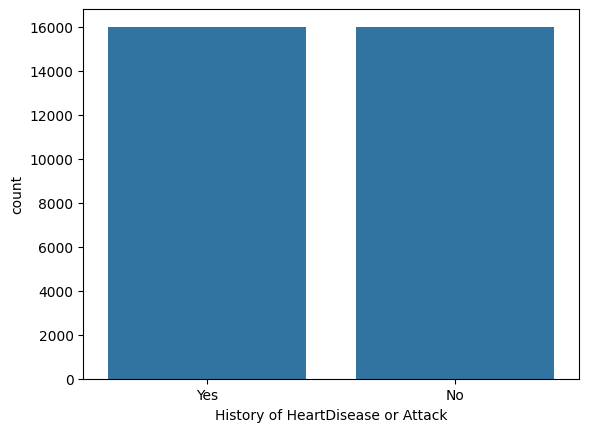

In [ ]:
sns.countplot(data=train_df, x='History of HeartDisease or Attack')

In [ ]:
features = train_df.columns.values[2:21]
features

array(['High Blood Pressure', 'Told High Cholesterol',
       'Cholesterol Checked', 'Body Mass Index', 'Smoked 100+ Cigarettes',
       'Diagnosed Stroke', 'Diagnosed Diabetes',
       'Leisure Physical Activity', 'Heavy Alcohol Consumption',
       'Health Care Coverage', 'Doctor Visit Cost Barrier',
       'General Health', 'Difficulty Walking', 'Sex', 'Education Level',
       'Income Level', 'Age', 'Vegetable or Fruit Intake (1+ per Day)'],
      dtype=object)

In [ ]:
train_dup = []
test_dup = []
for i in features:
    f = train_df[i].value_counts()
    train_dup.append([i,f.max(),f.idxmax()])
    f = test_df[i].value_counts()
    test_dup.append([i,f.max(),f.idxmax()])
train_dup = pd.DataFrame(train_dup,columns=["Feature","Dup","Value"])
test_dup = pd.DataFrame(test_dup,columns=["Feature","Dup","Value"])

In [ ]:
train_dup

In [ ]:
test_dup

# **Analysis Data**

<Axes: xlabel='History of HeartDisease or Attack', ylabel='count'>

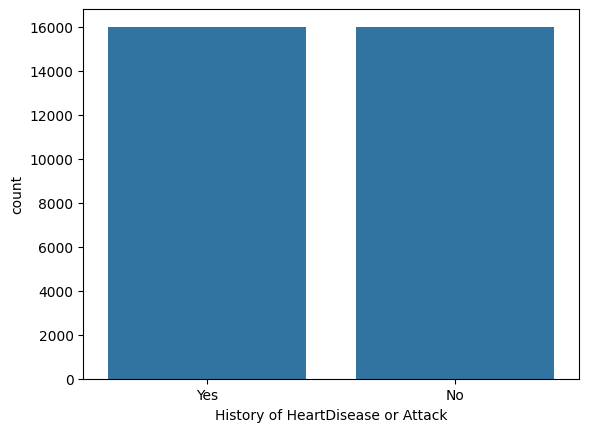

In [ ]:
df_yes = train_df[train_df['History of HeartDisease or Attack'] == "Yes"].sample(n=16000, random_state=42)
df_no = train_df[train_df['History of HeartDisease or Attack'] == "No"].sample(n=16000, random_state=42)
train_df = pd.concat([df_yes,df_no],ignore_index = True)
sns.countplot(data=train_df, x='History of HeartDisease or Attack')

In [ ]:
train_df_tmp = train_df.copy()
test_df_tmp = test_df.copy()

In [ ]:
general_health = {'Excellent':2,'Good':1,'Fair':0,'Poor':-1,'Very Poor':-2}
income_level = {'$75,000 or more':8,'$50,000 to less than $75,000':7,'$35,000 to less than $50,000':6,'$25,000 to less than $35,000':5,'$20,000 to less than $25,000':4,'$15,000 to less than $20,000':3,'($10,000 to less than $15,000':2,'Less than $10,000':1}
yes_no = {'Yes':1,'No':0}
sex = {'Male':1,'Female':0}
yes_no_col_train = ['History of HeartDisease or Attack','High Blood Pressure','Told High Cholesterol','Cholesterol Checked','Smoked 100+ Cigarettes','Diagnosed Stroke','Diagnosed Diabetes','Leisure Physical Activity','Heavy Alcohol Consumption','Doctor Visit Cost Barrier','Difficulty Walking','Vegetable or Fruit Intake (1+ per Day)','Health Care Coverage']
yes_no_col_test = ['High Blood Pressure','Told High Cholesterol','Cholesterol Checked','Smoked 100+ Cigarettes','Diagnosed Stroke','Diagnosed Diabetes','Leisure Physical Activity','Heavy Alcohol Consumption','Doctor Visit Cost Barrier','Difficulty Walking','Vegetable or Fruit Intake (1+ per Day)','Health Care Coverage']

In [ ]:
train_df_tmp[yes_no_col_train] = train_df_tmp[yes_no_col_train].replace(yes_no)
train_df_tmp['General Health'] = train_df_tmp['General Health'].replace(general_health)
train_df_tmp['Income Level'] = train_df_tmp['Income Level'].replace(income_level)
train_df_tmp['Sex'] = train_df_tmp['Sex'].replace(sex)
train_df_tmp.drop(['Education Level'], axis = 1,inplace = True)
train_df_tmp = train_df_tmp.dropna()

test_df_tmp[yes_no_col_test] = test_df_tmp[yes_no_col_test].replace(yes_no)
test_df_tmp['General Health'] = test_df_tmp['General Health'].replace(general_health)
test_df_tmp['Income Level'] = test_df_tmp['Income Level'].replace(income_level)
test_df_tmp['Sex'] = test_df_tmp['Sex'].replace(sex)
test_df_tmp.drop(['Education Level'], axis = 1,inplace = True)
test_df_tmp = test_df_tmp.dropna()

In [ ]:
train_df_tmp.drop(['Sex'], axis = 1,inplace = True)
train_df_tmp.drop(['Body Mass Index'], axis = 1,inplace = True)
train_df_tmp.drop(['Leisure Physical Activity'], axis = 1,inplace = True)
train_df_tmp.drop(['Smoked 100+ Cigarettes'], axis = 1,inplace = True)
train_df_tmp.drop(['Health Care Coverage'], axis = 1,inplace = True)
train_df_tmp.drop(['Cholesterol Checked'], axis = 1,inplace = True)
train_df_tmp.drop(['Vegetable or Fruit Intake (1+ per Day)'], axis = 1,inplace = True)
train_df_tmp.drop(['Doctor Visit Cost Barrier'], axis = 1,inplace = True)
train_df_tmp.drop(['ID'], axis = 1,inplace = True)

test_df_tmp.drop(['Sex'], axis = 1,inplace = True)
test_df_tmp.drop(['Body Mass Index'], axis = 1,inplace = True)
test_df_tmp.drop(['Leisure Physical Activity'], axis = 1,inplace = True)
test_df_tmp.drop(['Smoked 100+ Cigarettes'], axis = 1,inplace = True)
test_df_tmp.drop(['Health Care Coverage'], axis = 1,inplace = True)
test_df_tmp.drop(['Cholesterol Checked'], axis = 1,inplace = True)
test_df_tmp.drop(['Vegetable or Fruit Intake (1+ per Day)'], axis = 1,inplace = True)
test_df_tmp.drop(['Doctor Visit Cost Barrier'], axis = 1,inplace = True)
test_df_tmp.drop(['ID'], axis = 1,inplace = True)

In [ ]:
train_df_tmp

<Axes: >

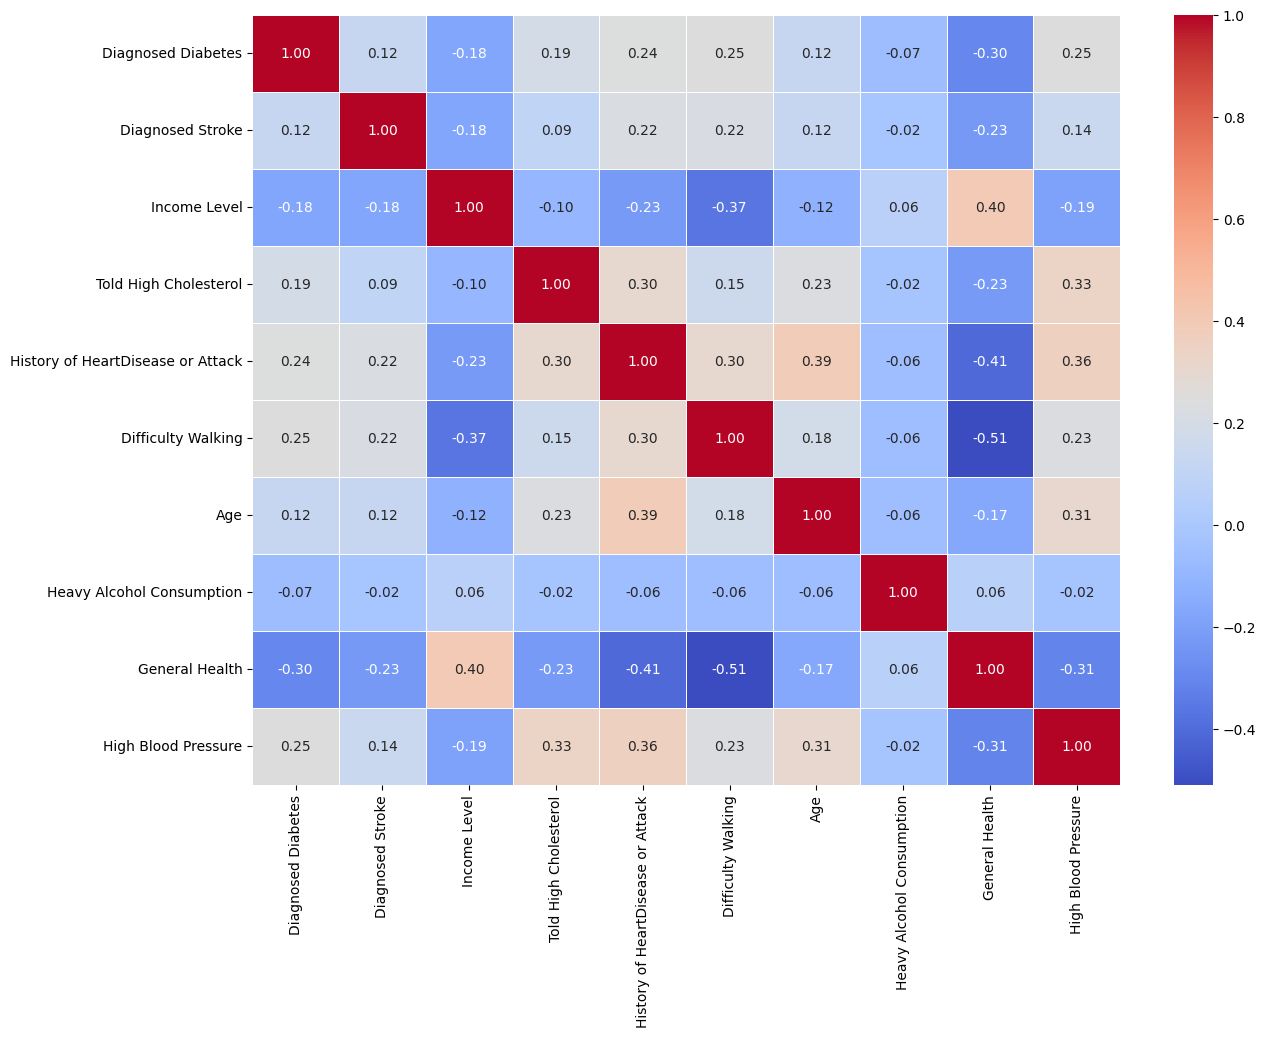

In [ ]:
numerical = list(set(train_df_tmp)-{'ID'})
corr_matrix = train_df_tmp[numerical].corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix,annot=True,fmt='.2f',cmap='coolwarm',linewidths=.5)

# **Feature Engineering**

In [ ]:
def feature_engineer(df):

    binary_map = {"Yes": 1, "No": 0}
    binary_cols = [
        "High Blood Pressure", "Told High Cholesterol", "Cholesterol Checked",
        "Smoked 100+ Cigarettes", "Diagnosed Stroke", "Diagnosed Diabetes",
        "Leisure Physical Activity", "Heavy Alcohol Consumption",
        "Health Care Coverage", "Doctor Visit Cost Barrier",
        "Difficulty Walking", "Vegetable or Fruit Intake (1+ per Day)"
    ]

    for col in binary_cols:
        if df[col].dtype == object:
            df[col + "_bin"] = df[col].map(binary_map)
        else:
            df[col + "_bin"] = df[col]


    def categorize_bmi(bmi):
        if bmi < 18.5:
            return "Underweight"
        elif bmi < 25:
            return "Normal weight"
        elif bmi < 30:
            return "Overweight"
        else:
            return "Obese"

    df['BMI Category'] = df['Body Mass Index'].apply(categorize_bmi)

    df['Obesity Risk'] = ((df['Body Mass Index'] >= 30) & (df['Leisure Physical Activity'] == 'No')).astype(int)

    columns_to_drop = [
        "High Blood Pressure_bin", "Told High Cholesterol_bin", "Cholesterol Checked_bin",
        "Smoked 100+ Cigarettes_bin", "Diagnosed Stroke_bin", "Diagnosed Diabetes_bin",
        "Leisure Physical Activity_bin", "Heavy Alcohol Consumption_bin",
        "Health Care Coverage_bin", "Doctor Visit Cost Barrier_bin",
        "Difficulty Walking_bin", "Vegetable or Fruit Intake (1+ per Day)_bin",
        "Leisure Physical Activity",
    ]
    df = df.drop(columns=columns_to_drop)
    return df

In [ ]:
features = train_df_tmp.columns.values[1:10]
def statistic(df):
    new_df = pd.DataFrame()
    new_df['mean'] = df[features].mean(axis=1)
    new_df['max'] = df[features].max(axis=1)
    new_df['std'] = df[features].std(axis=1)
    new_df['sum'] = df[features].sum(axis=1)
    new_df['skew'] = df[features].skew(axis=1)
    new_df['kurt'] = df[features].kurt(axis=1)
    return new_df

In [ ]:
train_df_tmp = statistic(train_df_tmp)
test_df_tmp = statistic(test_df_tmp)

In [ ]:
train_df_tmp

,mean,max,std,sum,skew,kurt
0,6.333333,47.0,15.491933,57.0,2.834050,8.199523
1,7.111111,59.0,19.477195,64.0,2.988764,8.950383
2,7.444444,58.0,19.144915,67.0,2.895537,8.494701
3,8.222222,64.0,20.945034,74.0,2.984680,8.929838
4,7.222222,56.0,18.437582,65.0,2.914070,8.589762
...,...,...,...,...,...,...
31993,5.111111,36.0,11.868492,46.0,2.757964,7.772672
31994,6.888889,52.0,17.113185,62.0,2.878357,8.404692
31995,8.333333,65.0,21.412613,75.0,2.917713,8.605670
31997,7.111111,56.0,18.530006,64.0,2.886963,8.449637


In [ ]:
train_df = feature_engineer(train_df)
test_df = feature_engineer(test_df)

In [ ]:
train_df['mean'] = train_df_tmp['mean']
train_df['max'] = train_df_tmp['max']
train_df['std'] = train_df_tmp['std']
train_df['sum'] = train_df_tmp['sum']
train_df['skew'] = train_df_tmp['skew']
train_df['kurt'] = train_df_tmp['kurt']

In [ ]:
test_df['mean'] = test_df_tmp['mean']
test_df['max'] = test_df_tmp['max']
test_df['std'] = test_df_tmp['std']
test_df['sum'] = test_df_tmp['sum']
test_df['skew'] = test_df_tmp['skew']
test_df['kurt'] = test_df_tmp['kurt']

In [ ]:
train_df

,ID,History of HeartDisease or Attack,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Heavy Alcohol Consumption,...,Age,Vegetable or Fruit Intake (1+ per Day),BMI Category,Obesity Risk,mean,max,std,sum,skew,kurt
0,train_183649,Yes,Yes,Yes,Yes,26.36,No,Yes,No,No,...,47,Yes,Overweight,0,6.333333,47.0,15.491933,57.0,2.834050,8.199523
1,train_001613,Yes,Yes,Yes,Yes,26.11,Yes,Yes,Yes,No,...,59,Yes,Overweight,0,7.111111,59.0,19.477195,64.0,2.988764,8.950383
2,train_072658,Yes,No,Yes,Yes,26.23,No,No,No,No,...,58,Yes,Overweight,0,7.444444,58.0,19.144915,67.0,2.895537,8.494701
3,train_217531,Yes,Yes,Yes,Yes,25.45,No,Yes,Yes,No,...,64,No,Overweight,0,8.222222,64.0,20.945034,74.0,2.984680,8.929838
4,train_220084,Yes,Yes,Yes,Yes,30.91,Yes,No,No,No,...,56,No,Obese,1,7.222222,56.0,18.437582,65.0,2.914070,8.589762
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31995,train_195215,No,No,No,Yes,24.25,No,No,No,No,...,65,Yes,Normal weight,0,8.333333,65.0,21.412613,75.0,2.917713,8.605670
31996,train_186665,No,No,NaN,No,30.33,No,No,No,No,...,41,No,Obese,1,NaN,NaN,NaN,NaN,NaN,NaN
31997,train_081417,No,No,No,Yes,21.50,Yes,No,No,Yes,...,56,Yes,Normal weight,0,7.111111,56.0,18.530006,64.0,2.886963,8.449637
31998,train_097050,No,Yes,Yes,Yes,NaN,Yes,No,No,No,...,61,Yes,Obese,0,NaN,NaN,NaN,NaN,NaN,NaN


# **Modeling**

In [ ]:
save_path = 'best_model'
hyperparameters = {
    'GBM': [
        {'ag_args_fit': {'num_gpus': 0}},
        {'ag_args_fit': {'num_gpus': 1}}
    ],
    'CAT': [
        {'ag_args_fit': {'num_gpus': 0}},
        {'ag_args_fit': {'num_gpus': 1}}
    ],
    'XGB': [
        {'ag_args_fit': {'num_gpus': 0}},
        {'ag_args_fit': {'num_gpus': 1}}
    ],
    'RF': [
        {'ag_args_fit': {'num_gpus': 0}},
        {'ag_args_fit': {'num_gpus': 1}}
    ],

}
time_limit=600

In [ ]:
f2_metric = make_scorer(name='f2',score_func=fbeta_score,optimum=1,greater_is_better=True,beta=2)

In [ ]:
predictor = TabularPredictor(label='History of HeartDisease or Attack',problem_type='binary',path=save_path,eval_metric=f2_metric)\
                            .fit(train_df,presets='best_quality',hyperparameters=hyperparameters,time_limit=time_limit)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          4
Pytorch Version:    2.9.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       44.74 GB / 47.05 GB (95.1%)
Disk Space Avail:   206.11 GB / 225.33 GB (91.5%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the d

# **Evaluation**

In [ ]:
predictor.leaderboard(train_df,silent = True)

In [ ]:
predictor.evaluate(train_df)

In [ ]:
predictions = predictor.predict(test_df)

# **Submission**

In [ ]:
sam_sub = pd.read_csv('/root/.cache/kagglehub/competitions/super-ai-engineer-ss-6-heart-disease-prediction/sample_submission.csv')
sam_sub

In [ ]:
sub = pd.DataFrame({
    'ID' : sam_sub['ID'],
    'History of HeartDisease or Attack' : predictions
})
sub.head()

In [ ]:
sub.to_csv('/content/submission_heart.csv', index=False)